# Paper-linked differential pair-rule results

## Setup

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    folder for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (folder / "result_summary" / "data_helper.py").exists()
)
sys.path[:0] = [
    str(ROOT / "result_summary"),
    str(ROOT / "result_summary" / "differential_rules"),
]

import data_helper as dh
import differential_stats as ds
import differential_vis as dv

warnings.filterwarnings("ignore")

STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]
SCORES = ["Pathological score", "Clinical score"]
METRIC = "Lift"
METRIC_REFERENCE = 1
MIN_CELLS = 20
MIN_ELIGIBLE = 3
MIN_PRESENT = 3
N_PERMUTATIONS = 5_000
DETAIL_FDR = 0.10
DETAIL_CHANGE = 0.30

PLOT_EXPORTS = {
    ("Colon", "Clinical score", "CD4T -> Plasma"): "tex_paper_colon_cd4_plasma.pdf",
    ("Colon", "Clinical score", "Plasma -> CD4T"): "tex_paper_colon_plasma_cd4.pdf",
    ("Colon", "Pathological score", "Macrophage -> CD4T"): "tex_paper_colon_macrophage_cd4.pdf",
    ("Duodenum", "Pathological score", "CD8T -> Goblet"): "tex_paper_duodenum_cd8_goblet.pdf",
    ("Duodenum", "Pathological score", "Goblet -> CD8T"): "tex_paper_duodenum_goblet_cd8.pdf",
}
FOV_EXPORTS = {
    ("Duodenum", "Pathological score", "Paneth -> Epithelial"): "tex_paper_paneth_epithelial_fovs.pdf",
    ("Duodenum", "Pathological score", "Endocrine -> Epithelial"): "tex_paper_endocrine_epithelial_fovs.pdf",
    ("Colon", "Clinical score", "CD4T -> Plasma"): "tex_paper_colon_cd4_plasma_fovs.pdf",
    ("Colon", "Pathological score", "Macrophage -> CD4T"): "tex_paper_colon_macrophage_cd4_fovs.pdf",
    ("Duodenum", "Pathological score", "CD8T -> Goblet"): "tex_paper_duodenum_cd8_goblet_fovs.pdf",
    ("Duodenum", "Pathological score", "Goblet -> CD8T"): "tex_paper_duodenum_goblet_cd8_fovs.pdf",
}

## Data

In [2]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(rule_max_items=2, kind=None)
rules = dh.prepare_rules(df_results)
rule_states, eligibility, eligible_states = ds.state_tables(
    rules, df_cells, df_fovs["FOV"], MIN_CELLS
)
print(f"{len(rules)} rows; {rules['Clean_Rule'].nunique()} directional pair rules")

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 9647 rules naming no Unidentified.
Kept 9647 rules (max_items=2, kind=None).
8693 rows; 525 directional pair rules


In [3]:
screens = {
    (organ, score): ds.severity_screen(
        eligible_states, df_fovs, organ, score, STAGES,
        min_eligible=MIN_ELIGIBLE,
        min_present=MIN_PRESENT,
        n_permutations=N_PERMUTATIONS,
    )
    for organ in ORGANS
    for score in SCORES
}
trend_results = {scope: result[0] for scope, result in screens.items()}
pair_results = {scope: result[1] for scope, result in screens.items()}

In [4]:
def family_table(rule_names):
    rows = []
    for organ in ORGANS:
        for score in SCORES:
            trend = trend_results[organ, score]
            pairs = pair_results[organ, score]
            for rule in rule_names:
                nets = {}
                for stage in STAGES:
                    fovs = ds.units_for(df_fovs, organ, score, stage)
                    nets[stage] = eligible_states.loc[rule, fovs].mean()
                fdrs = [trend.loc[rule, "fdr"]] if rule in trend.index else []
                fdrs += [result.loc[rule, "fdr"] for result in pairs.values()
                         if rule in result.index]
                rows.append({
                    "organ": organ, "score": score, "rule": rule,
                    **{f"net {stage}": 100 * nets[stage] for stage in STAGES},
                    "Control–Severe gap": 100 * abs(nets["Control"] - nets["Severe"]),
                    "best FDR": min(fdrs, default=np.nan),
                })
    table = pd.DataFrame(rows)
    table["detail"] = ((table["best FDR"] <= DETAIL_FDR)
                       | (table["Control–Severe gap"] >= 100 * DETAIL_CHANGE))
    return table.sort_values(["detail", "best FDR", "Control–Severe gap"],
                             ascending=[False, True, False])


In [5]:
def show_family(table):
    display(table.round(3).reset_index(drop=True))
    selected = table[table["detail"]]
    for row in selected.itertuples(index=False):
        spec = {"rule": row.rule, "organ": row.organ, "score": row.score}
        key = (row.organ, row.score, row.rule)
        dv.plot_rule_and_cell_changes(
            rule_states, eligibility, df_cells, df_fovs, [spec], STAGES,
            heading=f"{row.organ} {row.rule.replace(' -> ', ' → ')} beside cell abundance",
            trend_results=trend_results, pair_results=pair_results,
            save=PLOT_EXPORTS.get(key),
        )
        dv.plot_rule_metric(
            rules, eligibility, df_fovs, spec, STAGES,
            metric=METRIC, reference=METRIC_REFERENCE,
        )
        if key in FOV_EXPORTS:
            show_rule_fovs(spec)
    return selected


In [6]:
def show_rule_fovs(spec):
    key = (spec["organ"], spec["score"], spec["rule"])
    examples = ds.representative_fovs(
        rules, eligibility, df_fovs, spec["rule"], spec["organ"],
        spec["score"], STAGES, METRIC,
    )
    dv.plot_pair_rule_fovs(
        examples, STAGES, df_cells, df_fovs, spec["organ"], spec["score"],
        metric=METRIC, min_cells=MIN_CELLS, save=FOV_EXPORTS.get(key),
    )


## Results

### 1. Duodenum epithelial rules — pathological score

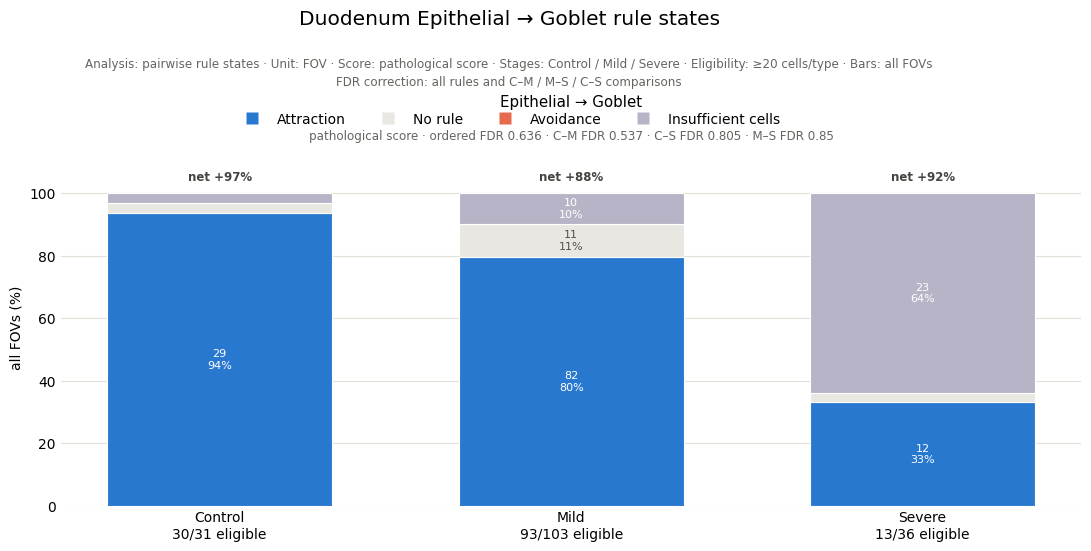

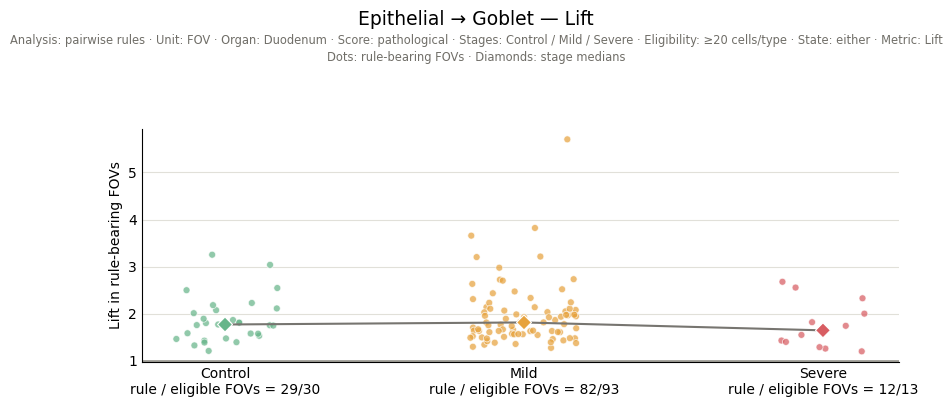

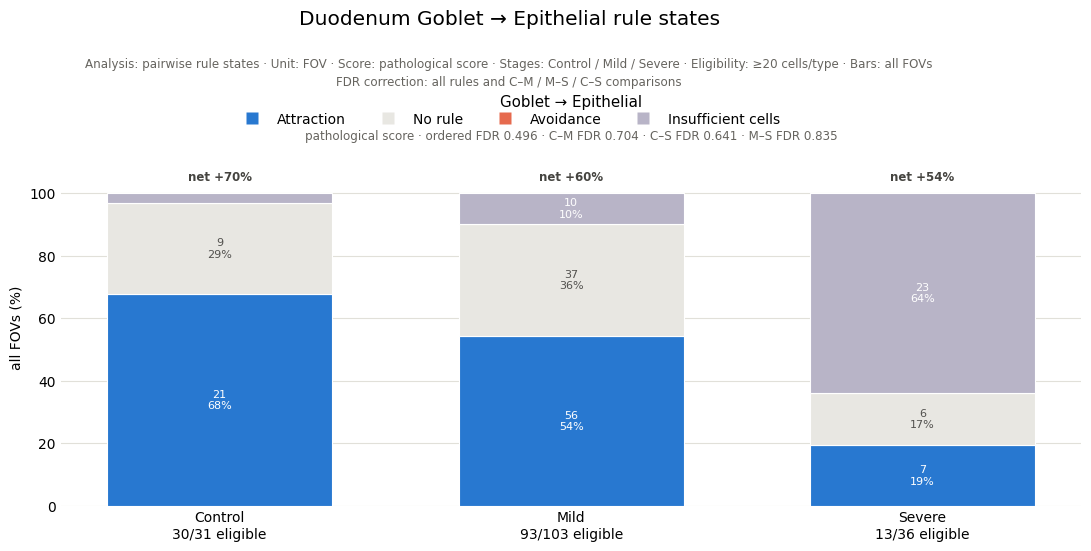

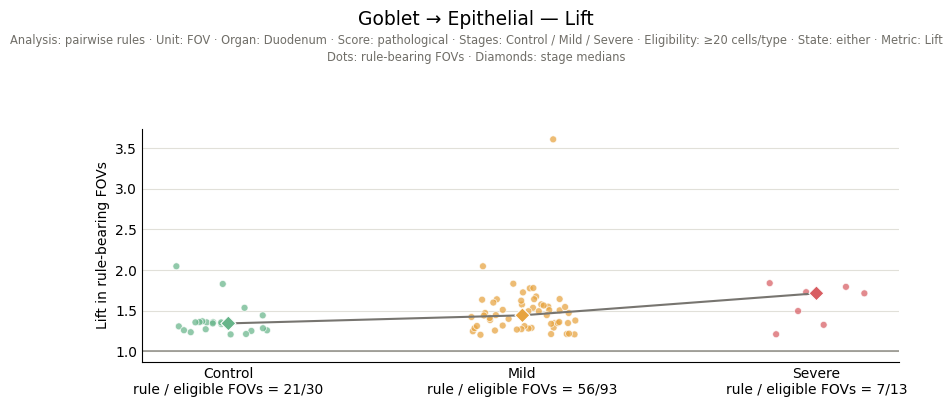

In [7]:
EPITHELIAL_SPECS = [
    {"rule": "Epithelial -> Goblet", "organ": "Duodenum", "score": "Pathological score"},
    {"rule": "Goblet -> Epithelial", "organ": "Duodenum", "score": "Pathological score"},
]
for spec in EPITHELIAL_SPECS:
    dv.plot_rule_states(
        rule_states, eligibility, df_fovs, [spec], STAGES,
        heading=f"Duodenum {spec['rule'].replace(' -> ', ' → ')} rule states",
        trend_results=trend_results, pair_results=pair_results,
    )
    dv.plot_rule_metric(
        rules, eligibility, df_fovs, spec, STAGES,
        metric=METRIC, reference=METRIC_REFERENCE,
    )


### 2. CD4T–Plasma–Macrophage rules — both organs and scores

,organ,score,rule,net Control,net Mild,net Severe,Control–Severe gap,best FDR,detail
0,Colon,Pathological score,CD4T -> Plasma,56.000,-10.000,5.882,50.118,0.016,True
1,Colon,Clinical score,CD4T -> Plasma,56.000,0.000,0.000,56.000,0.029,True
2,Colon,Pathological score,Macrophage -> CD4T,48.000,33.333,11.538,36.462,0.073,True
3,Colon,Clinical score,Macrophage -> CD4T,48.000,0.000,26.829,21.171,0.087,True
4,Colon,Clinical score,Plasma -> CD4T,48.000,0.000,16.667,31.333,0.174,True
5,Colon,Pathological score,Plasma -> CD4T,48.000,10.000,17.647,30.353,0.200,True
6,Duodenum,Pathological score,Macrophage -> CD4T,0.000,18.478,3.125,3.125,0.150,False
7,Colon,Clinical score,Macrophage -> Plasma,44.000,0.000,23.077,20.923,0.174,False
8,Colon,Pathological score,CD4T -> Macrophage,20.000,33.333,7.692,12.308,0.183,False
9,Duodenum,Clinical score,Macrophage -> CD4T,0.000,17.045,8.333,8.333,0.273,False


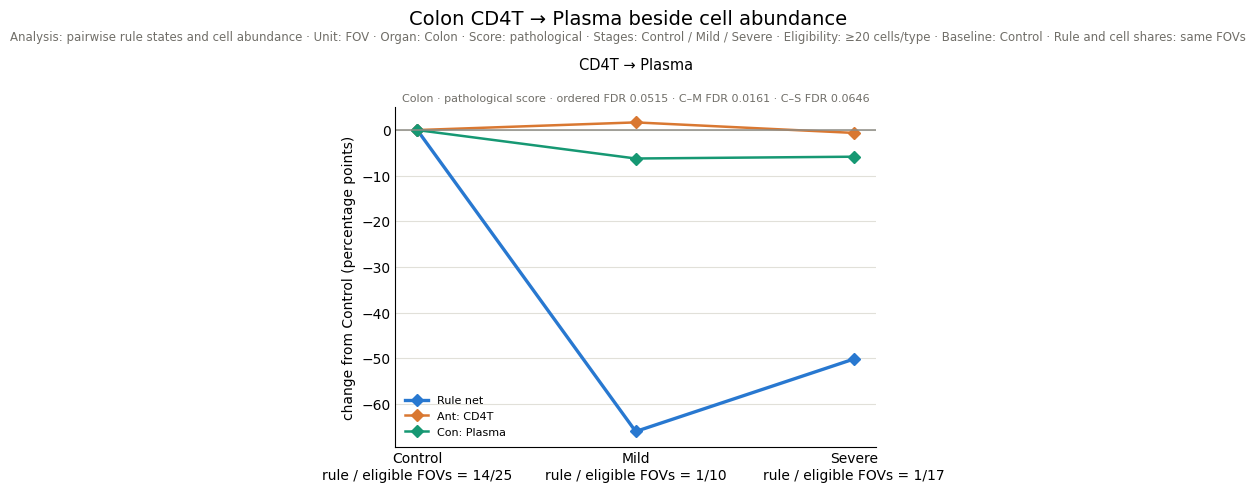

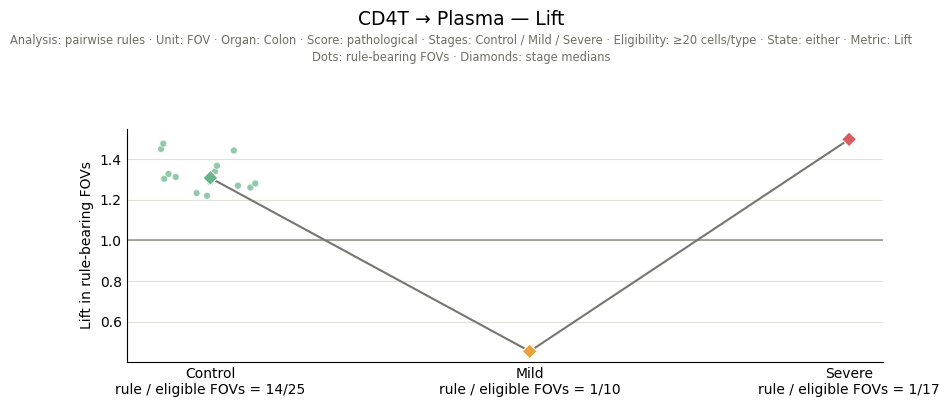

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_colon_cd4_plasma.pdf


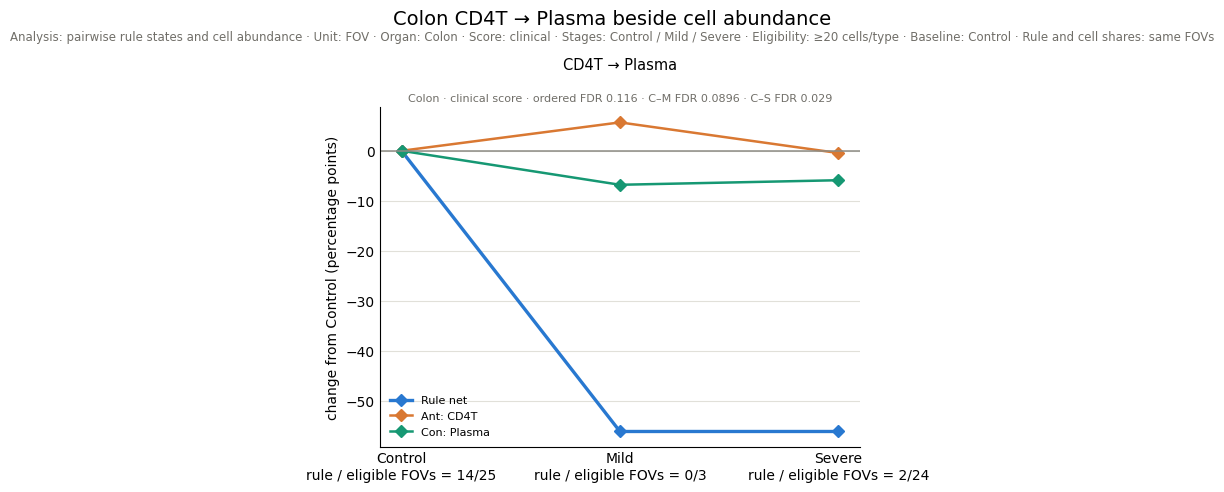

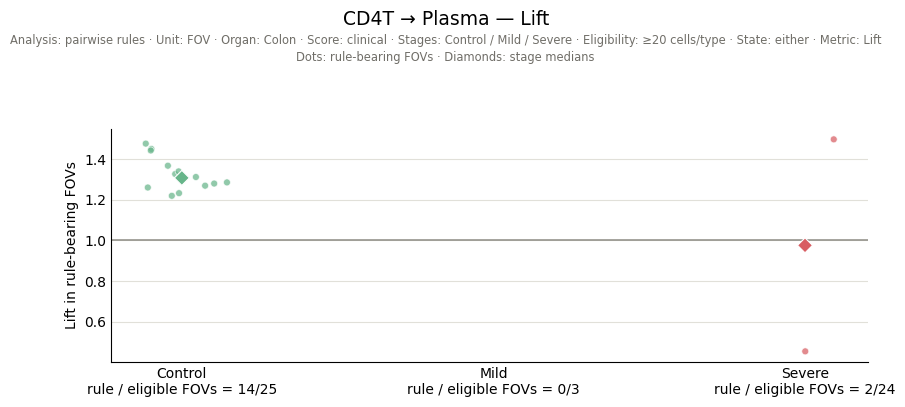

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_colon_cd4_plasma_fovs.pdf


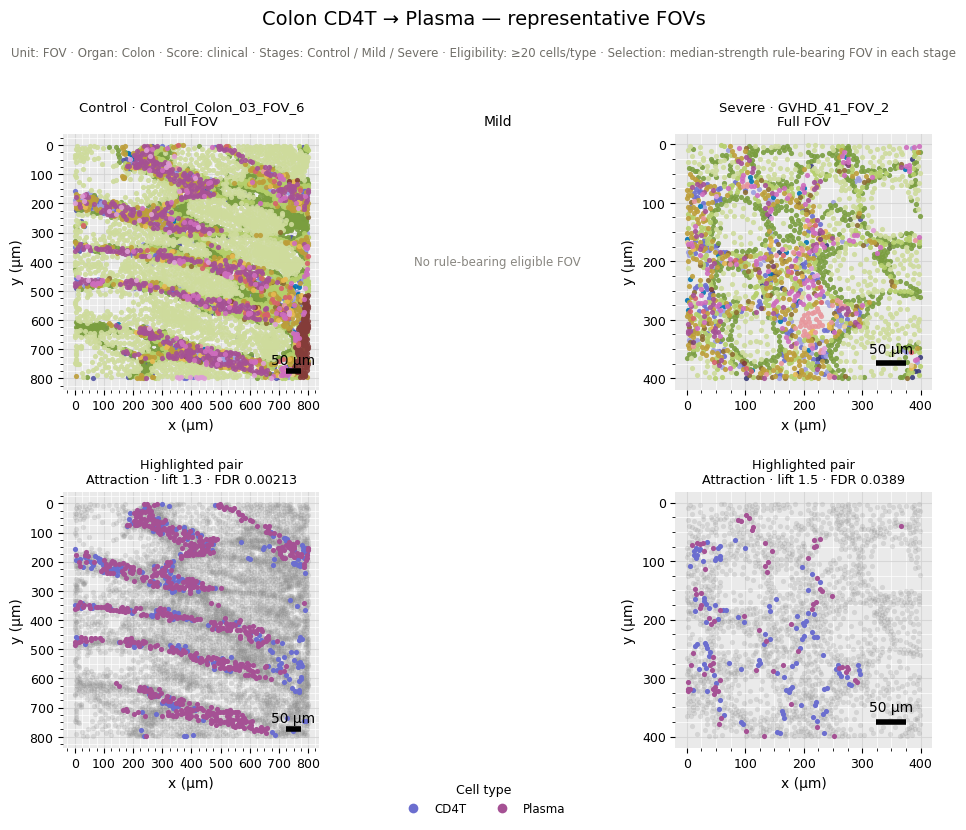

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_colon_macrophage_cd4.pdf


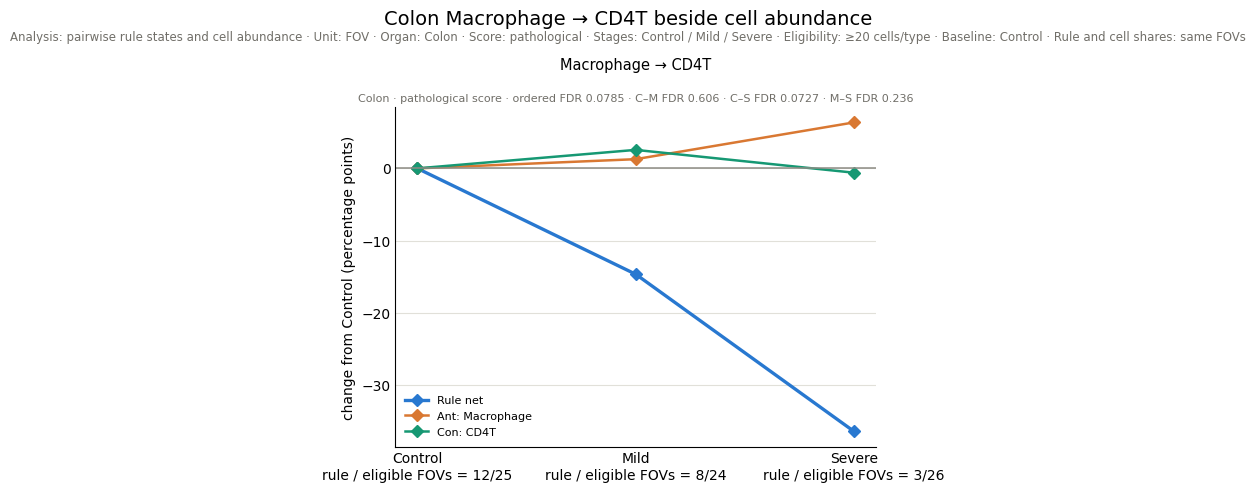

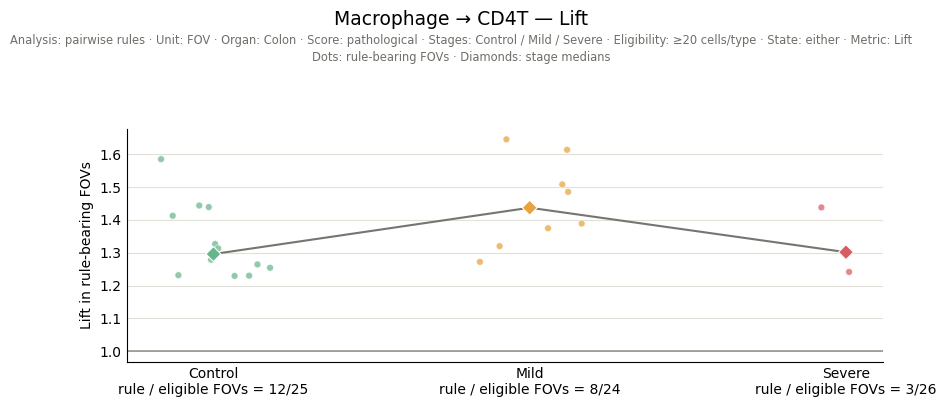

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_colon_macrophage_cd4_fovs.pdf


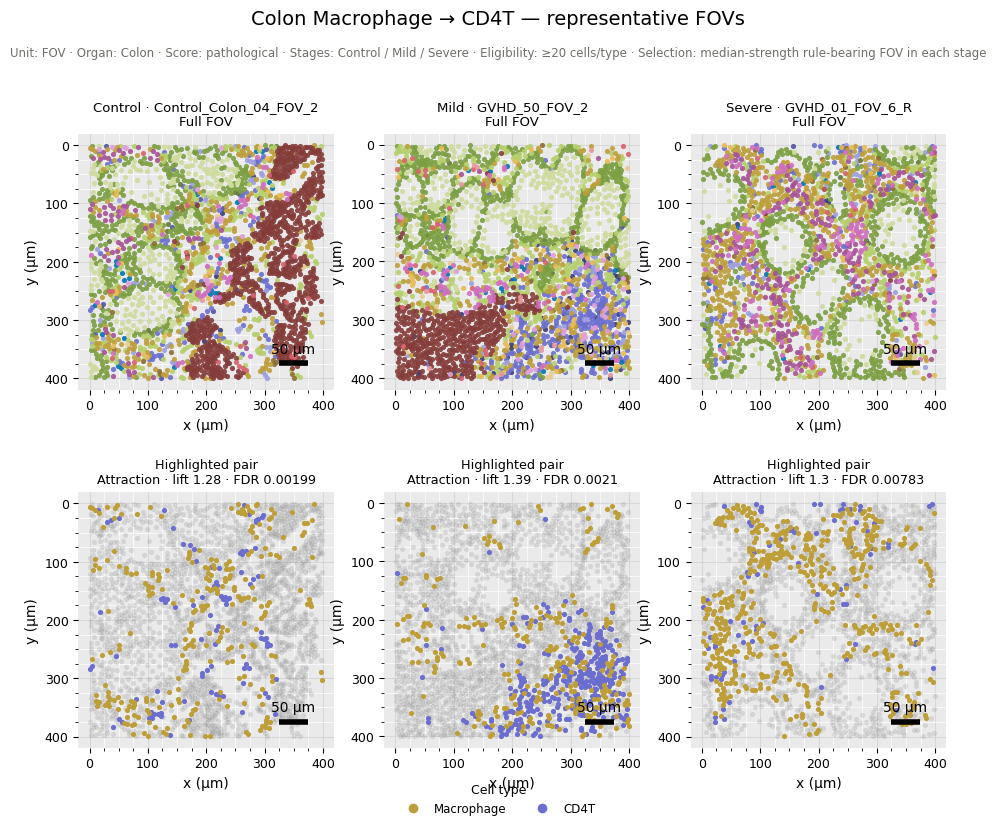

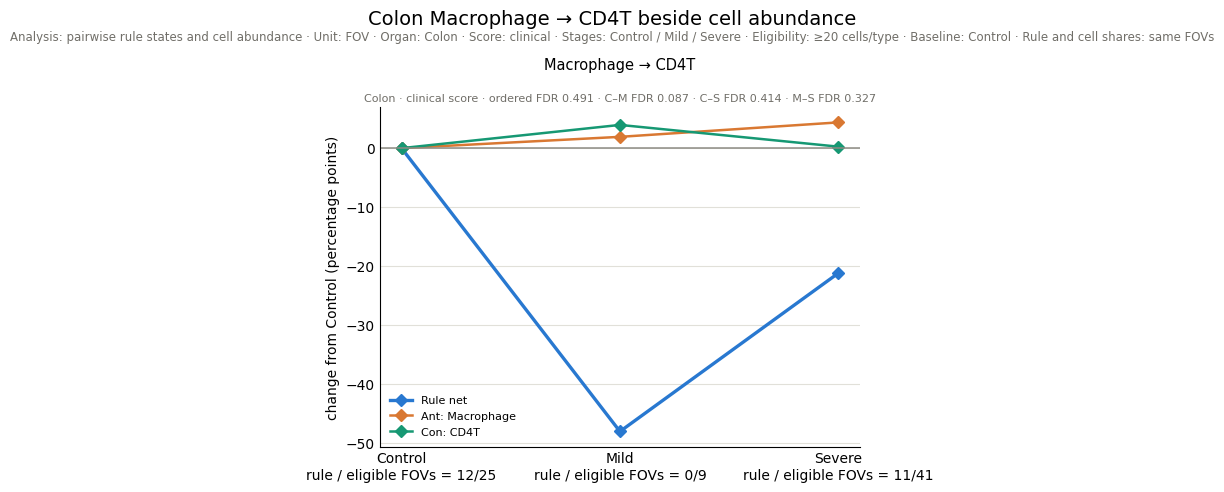

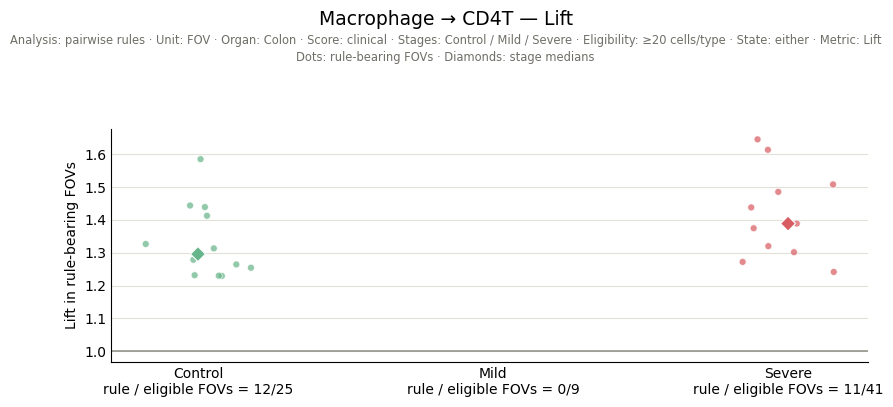

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_colon_plasma_cd4.pdf


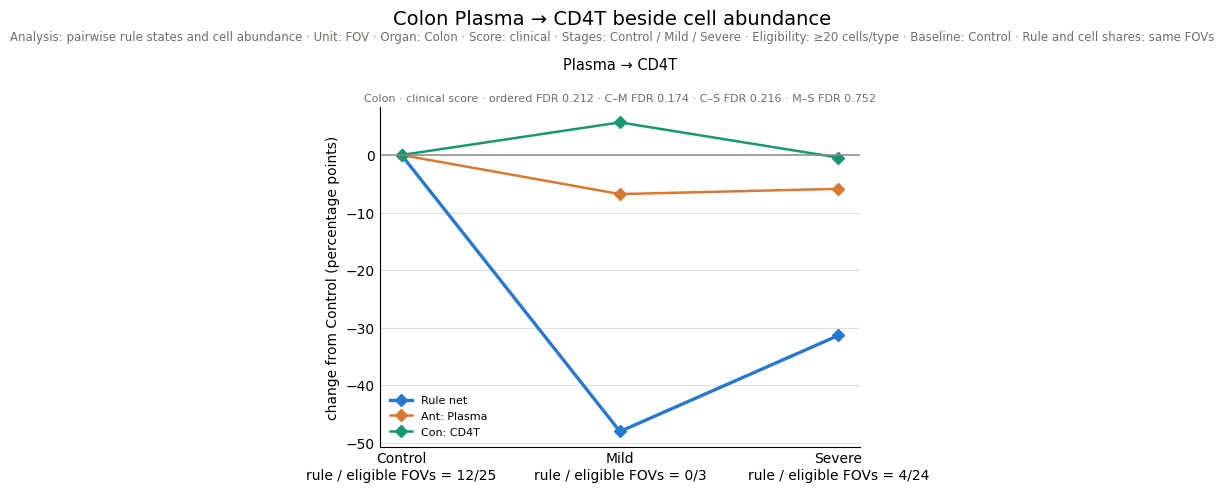

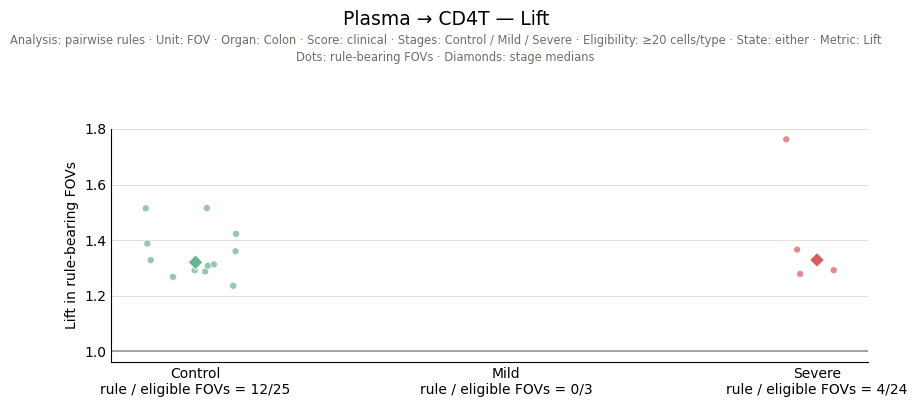

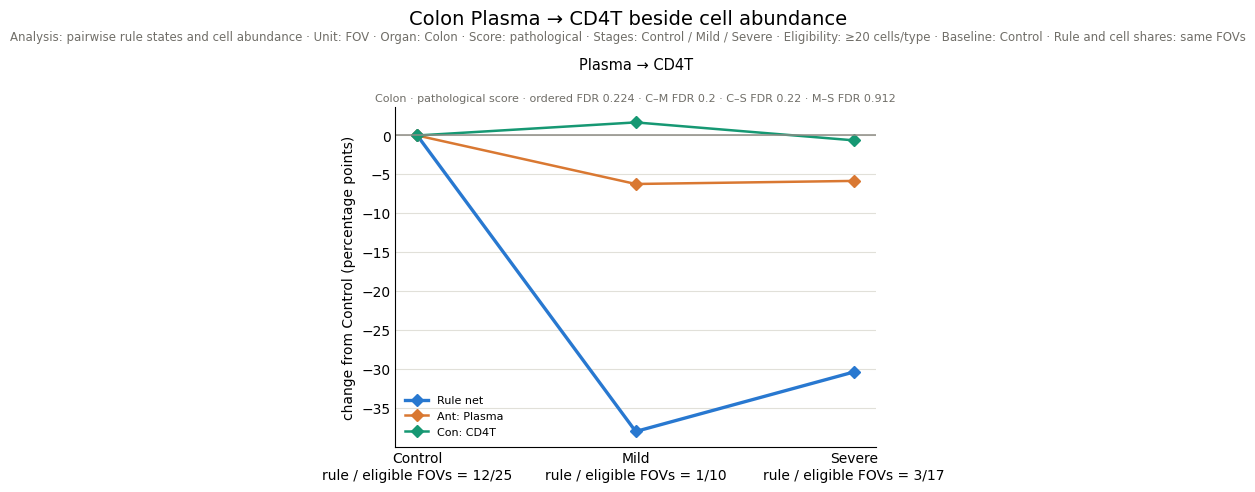

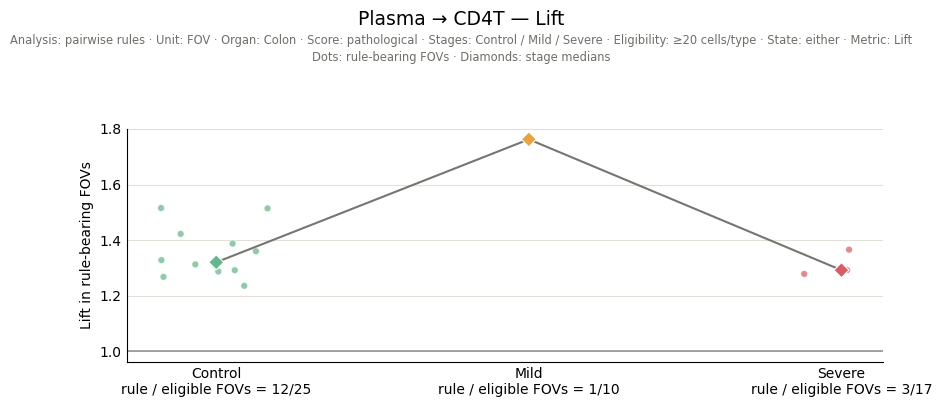

In [8]:
IMMUNE_CELLS = ["CD4T", "Plasma", "Macrophage"]
IMMUNE_RULES = [f"{source} -> {target}" for source in IMMUNE_CELLS
                for target in IMMUNE_CELLS if source != target]
immune_results = show_family(family_table(IMMUNE_RULES))


### 3. Duodenum Paneth rules — pathological score

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_paneth_to_epithelial.pdf


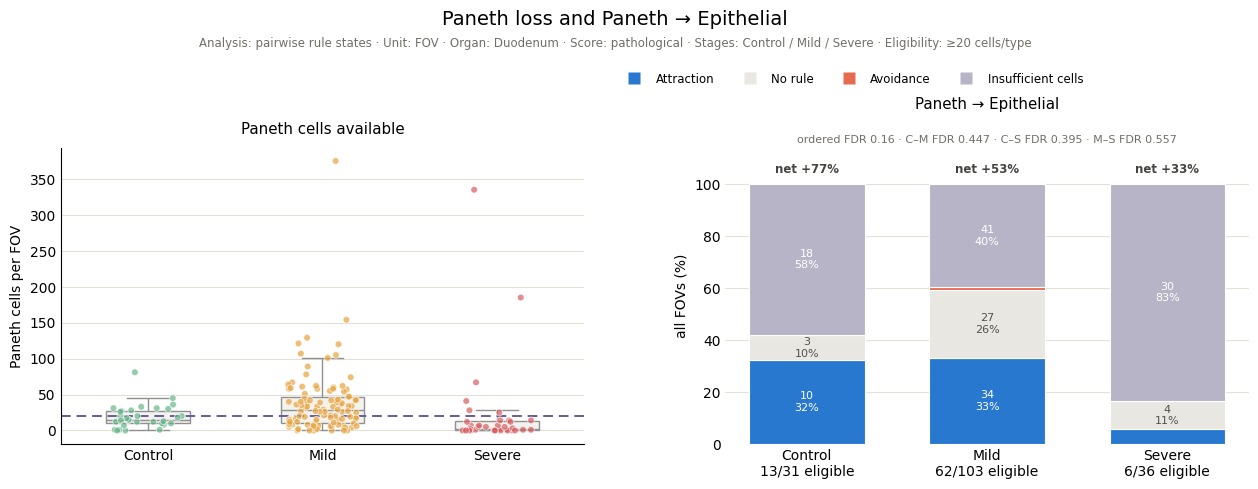

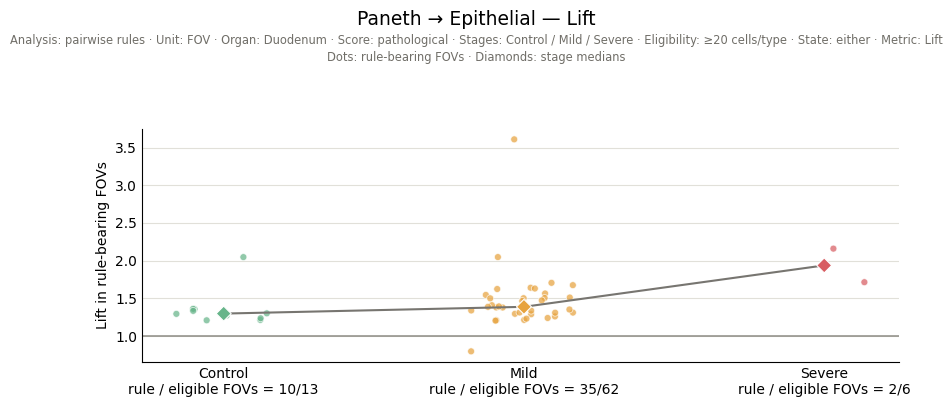

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_paneth_epithelial_fovs.pdf


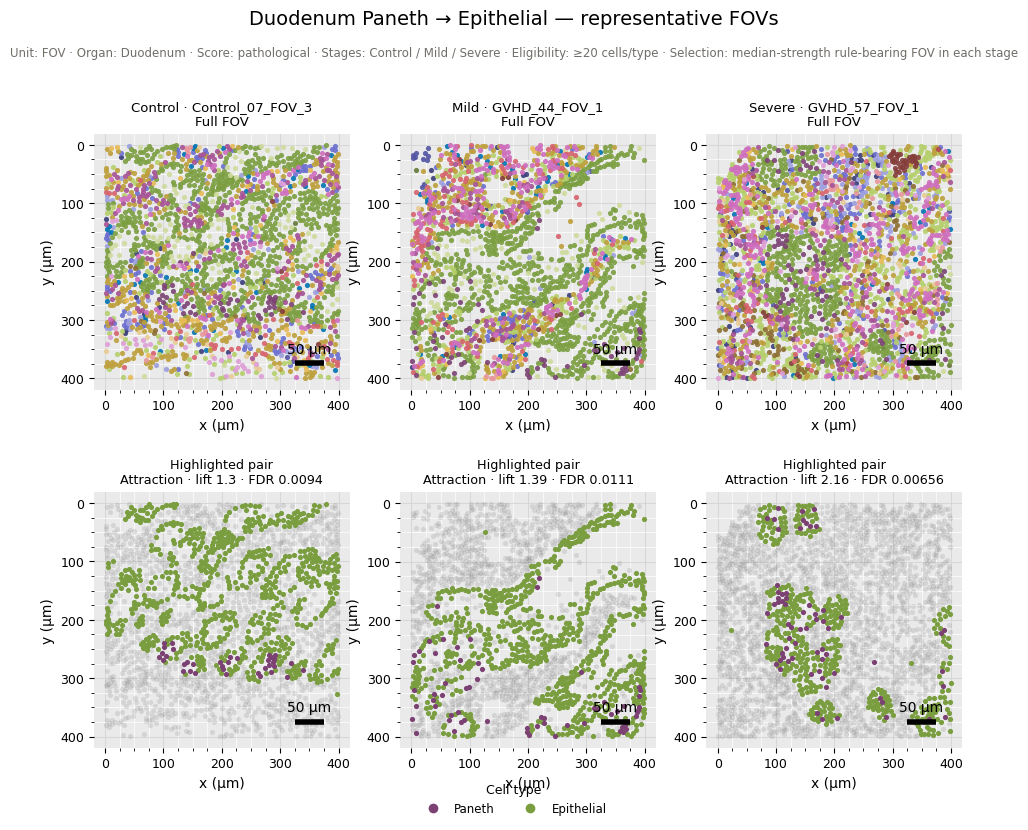

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_epithelial_to_paneth.pdf


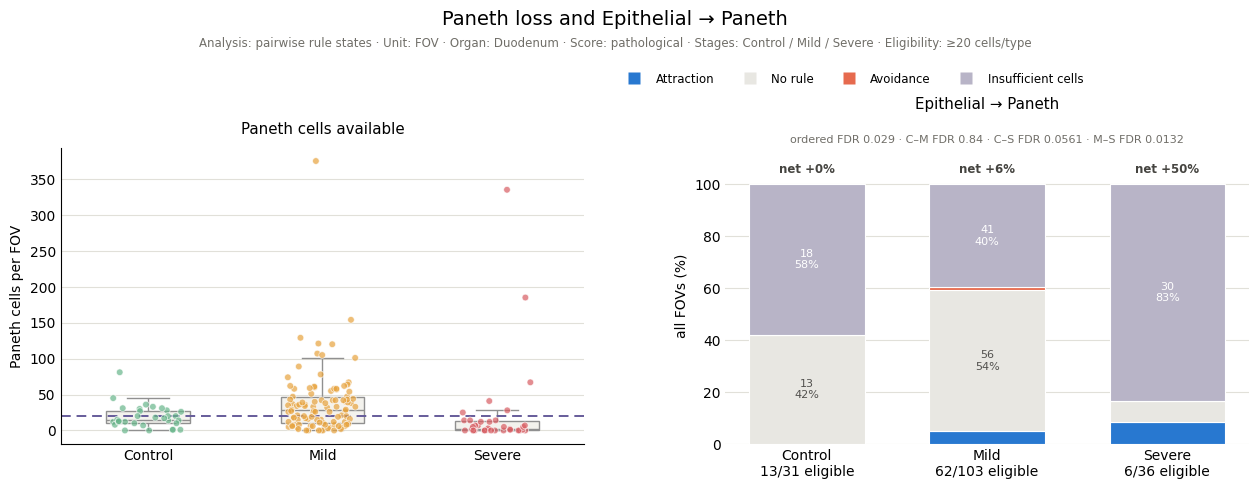

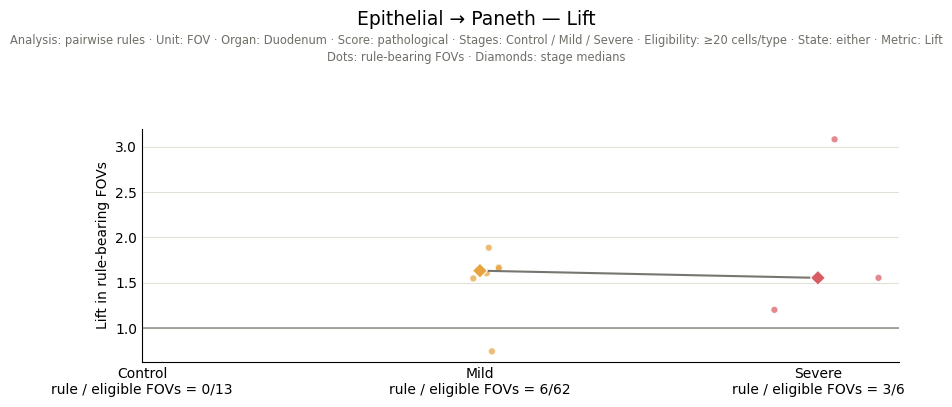

In [9]:
PANETH_RULES = [
    ({"rule": "Paneth -> Epithelial", "organ": "Duodenum", "score": "Pathological score"},
     "tex_paper_paneth_to_epithelial.pdf"),
    ({"rule": "Epithelial -> Paneth", "organ": "Duodenum", "score": "Pathological score"},
     "tex_paper_epithelial_to_paneth.pdf"),
]
for spec, filename in PANETH_RULES:
    dv.plot_rule_with_cell_count(
        rule_states, eligibility, df_cells, df_fovs, spec, "Paneth", STAGES,
        heading=f"Paneth loss and {spec['rule'].replace(' -> ', ' → ')}",
        trend_results=trend_results, pair_results=pair_results, save=filename,
    )
    dv.plot_rule_metric(
        rules, eligibility, df_fovs, spec, STAGES,
        metric=METRIC, reference=METRIC_REFERENCE,
    )
    if (spec['organ'], spec['score'], spec['rule']) in FOV_EXPORTS:
        show_rule_fovs(spec)


### 4. Duodenum Endocrine rule — pathological score

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_endocrine_context.pdf


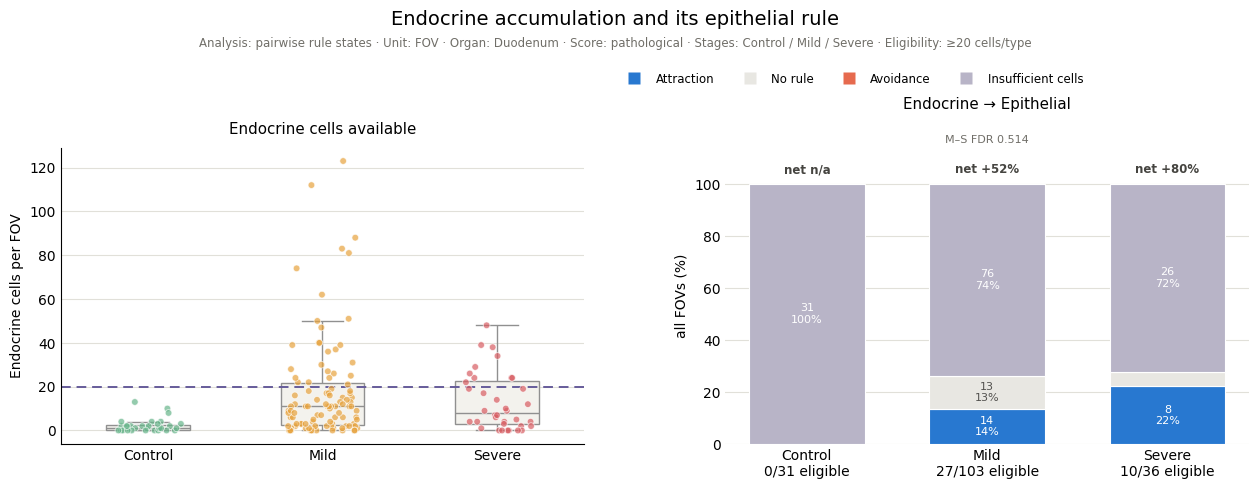

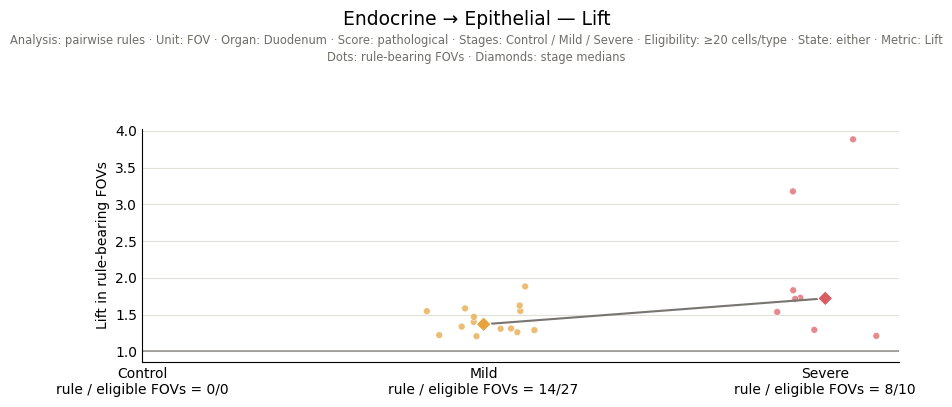

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_endocrine_epithelial_fovs.pdf


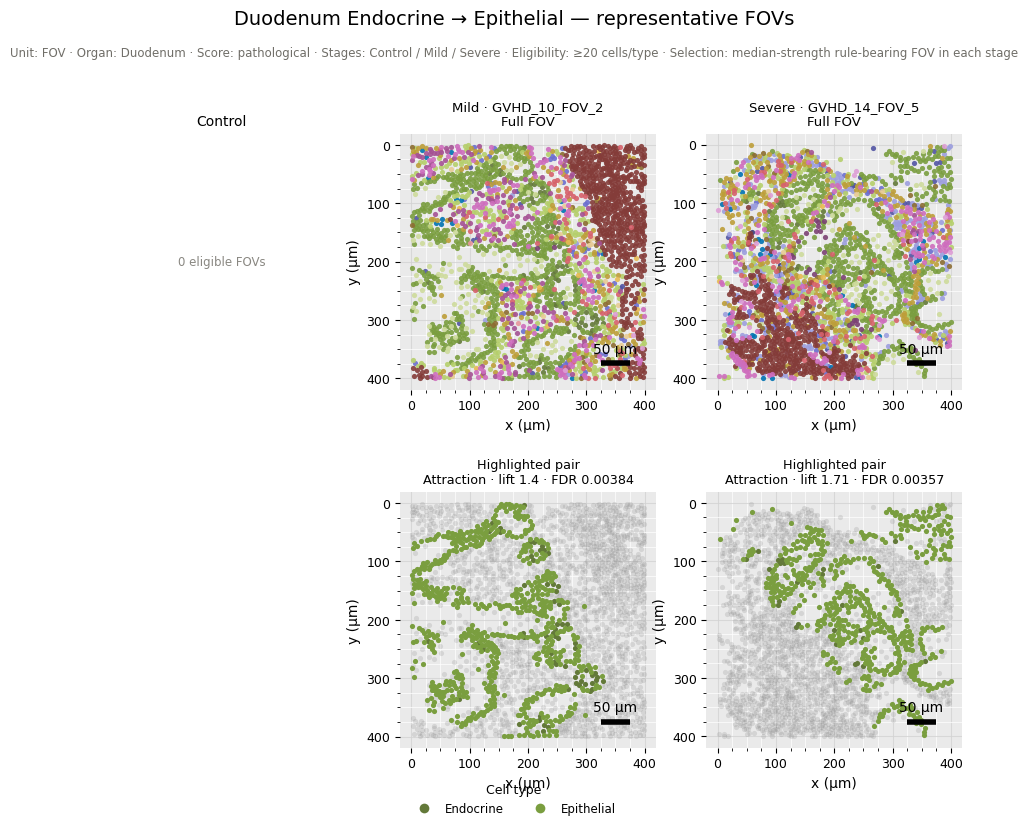

In [10]:
ENDOCRINE_EPITHELIAL = {"rule": "Endocrine -> Epithelial",
                         "organ": "Duodenum",
                         "score": "Pathological score"}
dv.plot_rule_with_cell_count(
    rule_states, eligibility, df_cells, df_fovs, ENDOCRINE_EPITHELIAL, "Endocrine",
    STAGES, heading="Endocrine accumulation and its epithelial rule",
    trend_results=trend_results, pair_results=pair_results,
    save="tex_paper_endocrine_context.pdf",
)
dv.plot_rule_metric(
    rules, eligibility, df_fovs, ENDOCRINE_EPITHELIAL, STAGES,
    metric=METRIC, reference=METRIC_REFERENCE,
)
show_rule_fovs(ENDOCRINE_EPITHELIAL)


### 5. CD8T–epithelial rules — both organs and scores

,organ,score,rule,net Control,net Mild,net Severe,Control–Severe gap,best FDR,detail
0,Duodenum,Pathological score,CD8T -> Goblet,-21.429,-22.000,-75.000,53.571,0.013,True
1,Duodenum,Pathological score,Goblet -> CD8T,-46.429,-58.000,-100.000,53.571,0.056,True
2,Duodenum,Clinical score,Goblet -> CD8T,-46.429,-56.098,-82.353,35.924,0.277,True
3,Duodenum,Clinical score,CD8T -> Goblet,-21.429,-19.512,-52.941,31.513,0.277,True
4,Colon,Pathological score,CD8T -> Goblet,-44.000,-16.000,-44.444,0.444,0.200,False
5,Colon,Pathological score,CD8T -> Epithelial,8.000,0.000,-3.226,11.226,0.335,False
6,Colon,Clinical score,CD8T -> Epithelial,8.000,-9.091,0.000,8.000,0.414,False
7,Colon,Clinical score,CD8T -> Goblet,-44.000,-18.182,-34.146,9.854,0.417,False
8,Colon,Clinical score,Goblet -> CD8T,-96.000,-100.000,-92.683,3.317,0.749,False
9,Duodenum,Pathological score,CD8T -> Epithelial,3.448,0.000,4.545,1.097,0.775,False


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_duodenum_cd8_goblet.pdf


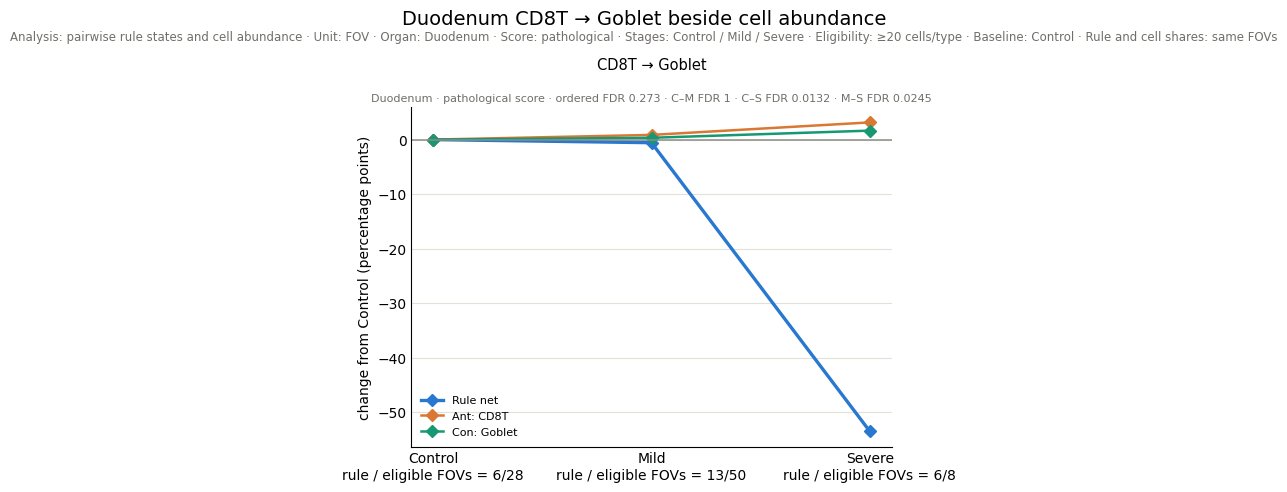

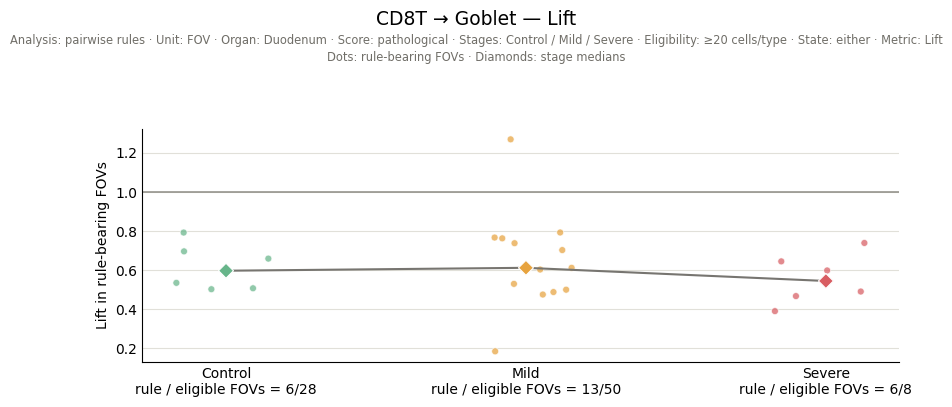

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_duodenum_cd8_goblet_fovs.pdf


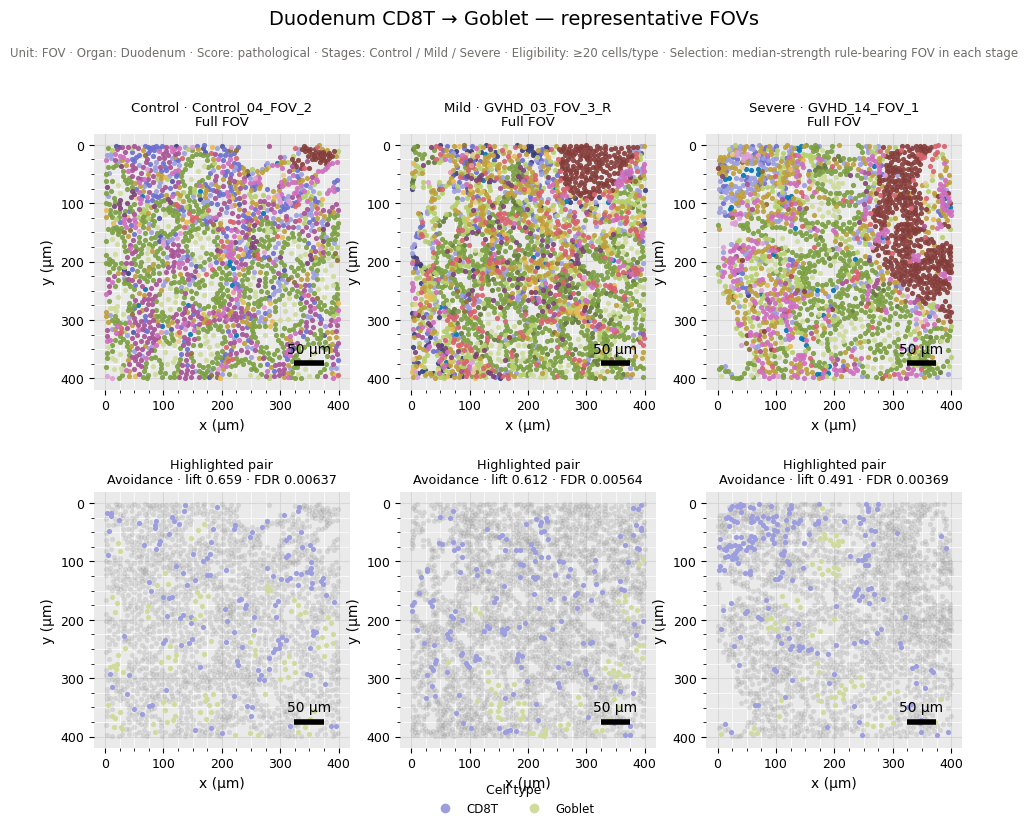

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_duodenum_goblet_cd8.pdf


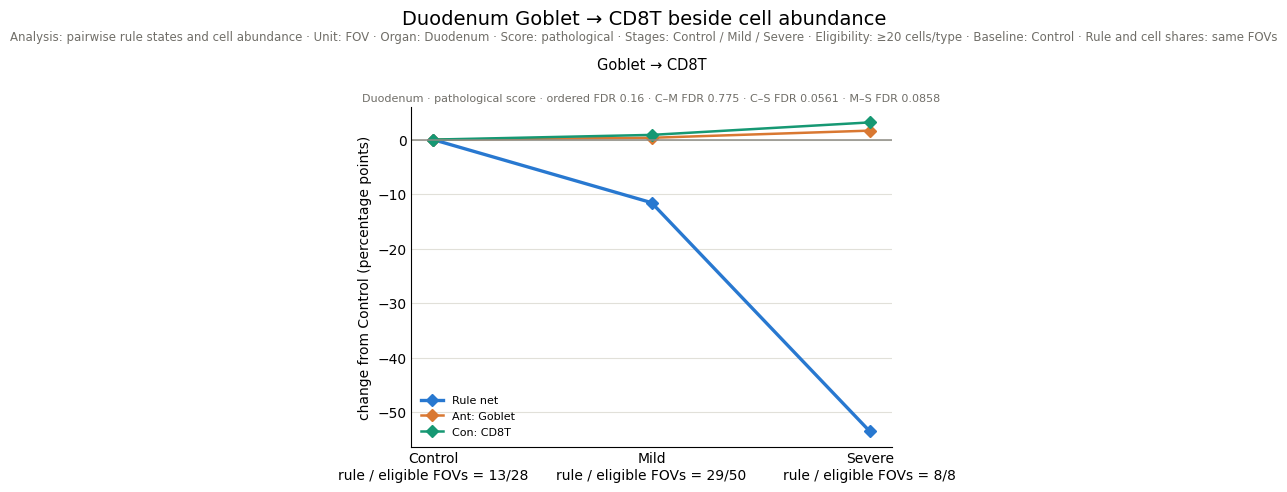

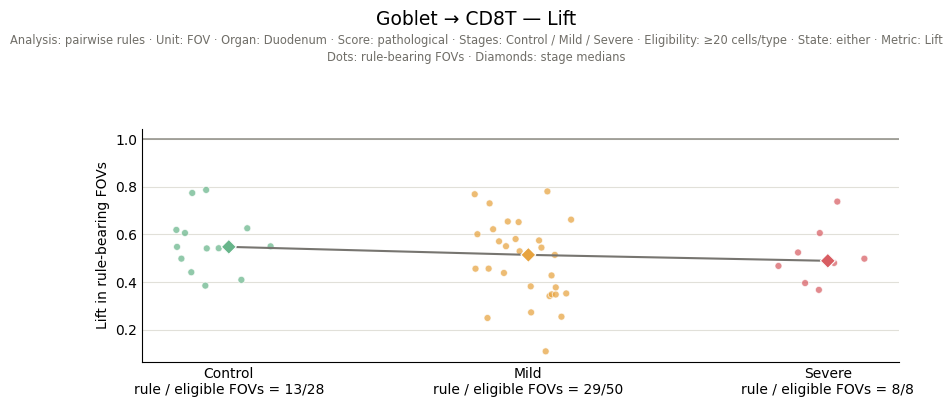

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\differential_rules\summary_downloads\tex_paper_duodenum_goblet_cd8_fovs.pdf


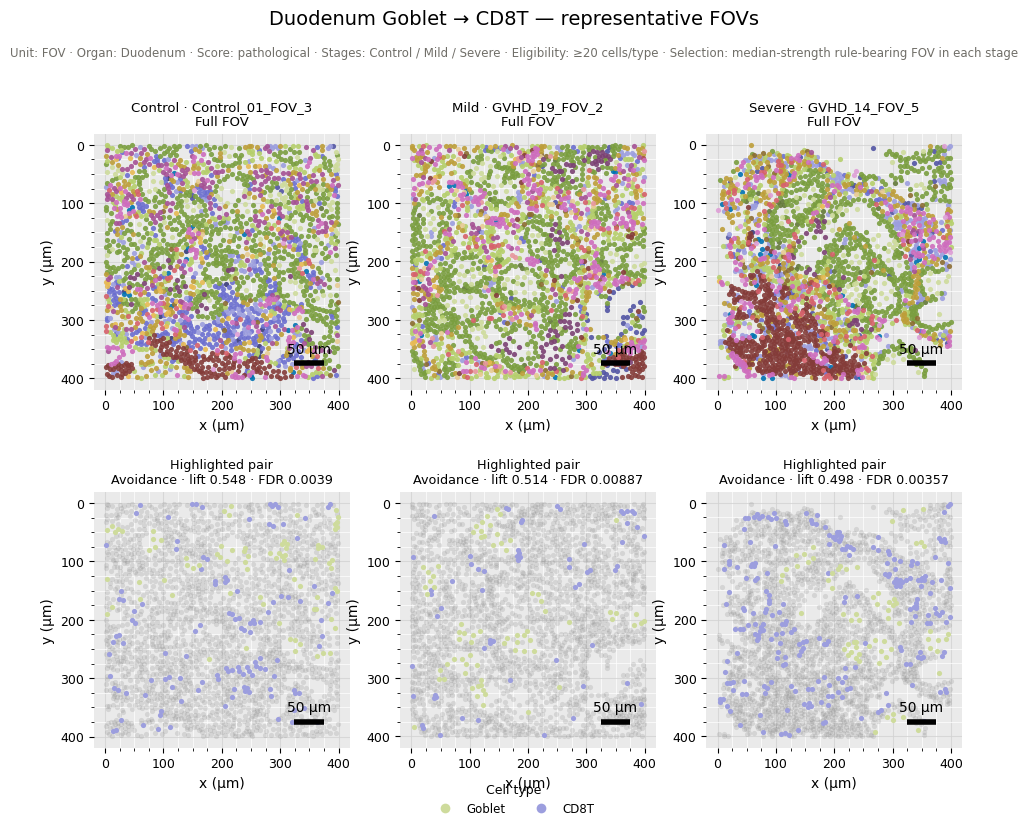

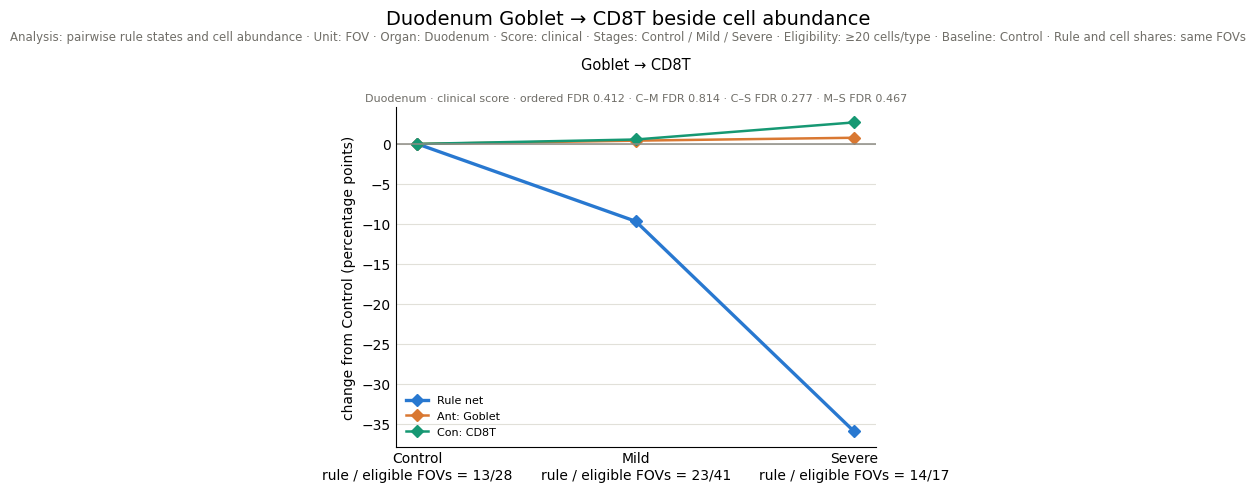

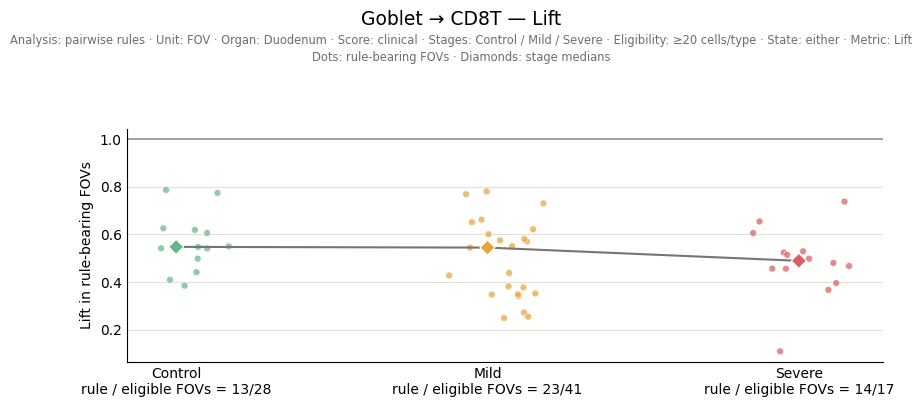

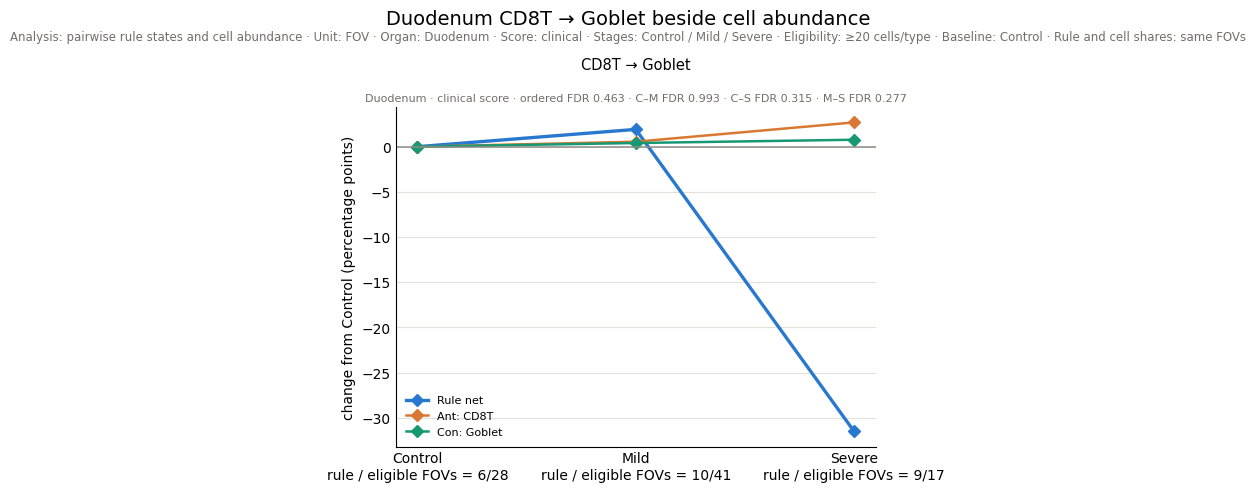

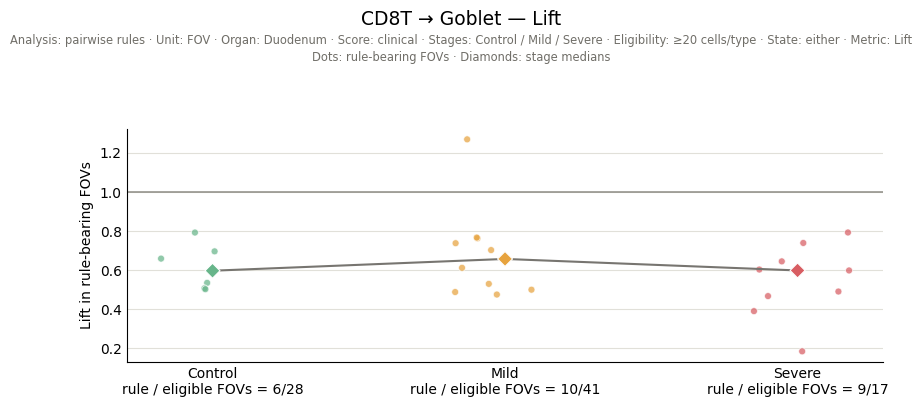

In [11]:
CD8_EPITHELIAL_RULES = [
    "CD8T -> Goblet", "Goblet -> CD8T",
    "CD8T -> Epithelial", "Epithelial -> CD8T",
]
cd8_results = show_family(family_table(CD8_EPITHELIAL_RULES))
